#**SimPy**

SimPy é uma biblioteca em Python para simulação de eventos discretos (DES).

*   Environment — controla o tempo e agenda eventos
*   Process — funções que usam yield para serem "pausadas"
*   Event — timeout, requisição de recurso, liberação
*   Resource — servidores, máquinas, berços, caixas etc.

## **Semáforo**

In [20]:
!pip install simpy
import simpy

def semaforo(env):
    while True:
        print(f"Verde    - Tempo: {env.now}")
        yield env.timeout(30)  # espera 30 unidades de tempo
        print(f"Amarelo  - Tempo: {env.now}")
        yield env.timeout(5)   # espera 5 unidades de tempo
        print(f"Vermelho - Tempo: {env.now}")
        yield env.timeout(20)  # espera 20 unidades de tempo

env = simpy.Environment()
env.process(semaforo(env))
env.run(until=300)

Verde    - Tempo: 0
Amarelo  - Tempo: 30
Vermelho - Tempo: 35
Verde    - Tempo: 55
Amarelo  - Tempo: 85
Vermelho - Tempo: 90
Verde    - Tempo: 110
Amarelo  - Tempo: 140
Vermelho - Tempo: 145
Verde    - Tempo: 165
Amarelo  - Tempo: 195
Vermelho - Tempo: 200
Verde    - Tempo: 220
Amarelo  - Tempo: 250
Vermelho - Tempo: 255
Verde    - Tempo: 275


# **Processo de Chegada e Atendimento**

# Papel do yield
Cada processo é modelado como:
*   yield env.timeout(T) → pausa o processo por T unidades de tempo
*   yield recurso.request() → aguarda recurso livre
*   yield evento → espera evento acontecer


In [21]:
!pip install simpy
import simpy
import random

def navio(env, nome, berço):
    print(f"{nome} chegou no tempo {env.now}")
    with berço.request() as req:
        yield req  # espera até o recurso estar disponível
        print(f"{nome} começou atendimento no tempo {env.now}")
        tempo_atendimento = random.randint(2, 5)
        yield env.timeout(tempo_atendimento)
        print(f"{nome} saiu no tempo {env.now}")

def chegada_de_navios(env, berço):
    i = 0
    while True:
        yield env.timeout(random.randint(1, 3))
        i += 1
        env.process(navio(env, f"Navio {i}", berço))

env = simpy.Environment()
berço = simpy.Resource(env, capacity=1)
env.process(chegada_de_navios(env, berço))
env.run(until=100)

Navio 1 chegou no tempo 2
Navio 1 começou atendimento no tempo 2
Navio 1 saiu no tempo 4
Navio 2 chegou no tempo 5
Navio 2 começou atendimento no tempo 5
Navio 3 chegou no tempo 6
Navio 2 saiu no tempo 7
Navio 3 começou atendimento no tempo 7
Navio 4 chegou no tempo 8
Navio 3 saiu no tempo 10
Navio 5 chegou no tempo 10
Navio 4 começou atendimento no tempo 10
Navio 6 chegou no tempo 11
Navio 4 saiu no tempo 13
Navio 7 chegou no tempo 13
Navio 5 começou atendimento no tempo 13
Navio 8 chegou no tempo 14
Navio 9 chegou no tempo 15
Navio 5 saiu no tempo 18
Navio 10 chegou no tempo 18
Navio 6 começou atendimento no tempo 18
Navio 11 chegou no tempo 19
Navio 12 chegou no tempo 20
Navio 13 chegou no tempo 21
Navio 6 saiu no tempo 22
Navio 7 começou atendimento no tempo 22
Navio 14 chegou no tempo 23
Navio 7 saiu no tempo 25
Navio 8 começou atendimento no tempo 25
Navio 15 chegou no tempo 26
Navio 16 chegou no tempo 27
Navio 17 chegou no tempo 28
Navio 8 saiu no tempo 29
Navio 9 começou atendi

## **Fila M/M/1**

In [22]:
!pip install simpy

import simpy
import random
import statistics
import math

# ----------------------
# PARÂMETROS DO MODELO
# ----------------------
LAMBDA = 1/5   # taxa de chegada (λ)
MU = 1/3       # taxa de serviço (μ)
TEMPO_SIM = 50000  # tempo de simulação

tempos_espera = []
tempos_sistema = []
total_clientes = 0

def cliente(env, nome, servidor):
    global total_clientes
    chegada = env.now
    total_clientes += 1

    with servidor.request() as req:
        yield req

        espera = env.now - chegada
        tempos_espera.append(espera)

        # Tempo de serviço ~ Exp(MU)
        tempo_servico = random.expovariate(MU)
        yield env.timeout(tempo_servico)

        saida = env.now
        tempos_sistema.append(saida - chegada)

def chegadas(env, servidor):
    i = 0
    while True:
        # Intervalo entre chegadas ~ Exp(LAMBDA)
        intervalo = random.expovariate(LAMBDA)
        yield env.timeout(intervalo)
        i += 1
        env.process(cliente(env, f"Cliente {i}", servidor))

# Ambiente
env = simpy.Environment()
servidor = simpy.Resource(env, capacity=1)

env.process(chegadas(env, servidor))
env.run(until=TEMPO_SIM)

# ----------------------
# TEORIA M/M/1
# ----------------------
def teorico_mm1(lmbd, mu):
    rho = lmbd / mu
    if rho >= 1:
        raise ValueError("Sistema instável: λ >= μ")

    L = rho / (1 - rho)
    Lq = rho**2 / (1 - rho)
    W = 1 / (mu - lmbd)
    Wq = lmbd / (mu * (mu - lmbd))
    P0 = 1 - rho

    return {
        "rho": rho,
        "L": L,
        "Lq": Lq,
        "W": W,
        "Wq": Wq,
        "P0": P0
    }

teo = teorico_mm1(LAMBDA, MU)

print("\n===== RESULTADOS DA SIMULAÇÃO M/M/1 =====")
print(f"Clientes atendidos: {total_clientes}")
print(f"Tempo médio de espera Wq (sim): {statistics.mean(tempos_espera):.4f}")
print(f"Tempo médio no sistema W  (sim): {statistics.mean(tempos_sistema):.4f}")

print("\n===== RESULTADOS TEÓRICOS M/M/1 =====")
print(f"ρ   = {teo['rho']:.4f}")
print(f"Lq  = {teo['Lq']:.4f}")
print(f"L   = {teo['L']:.4f}")
print(f"Wq  = {teo['Wq']:.4f}")
print(f"W   = {teo['W']:.4f}")

print("\n===== COMPARAÇÃO DIRETA =====")
print(f"Wq sim ≈ {statistics.mean(tempos_espera):.4f}  | Wq teo = {teo['Wq']:.4f}")
print(f"W  sim ≈ {statistics.mean(tempos_sistema):.4f}  | W  teo = {teo['W']:.4f}")


===== RESULTADOS DA SIMULAÇÃO M/M/1 =====
Clientes atendidos: 9943
Tempo médio de espera Wq (sim): 4.4322
Tempo médio no sistema W  (sim): 7.4075

===== RESULTADOS TEÓRICOS M/M/1 =====
ρ   = 0.6000
Lq  = 0.9000
L   = 1.5000
Wq  = 4.5000
W   = 7.5000

===== COMPARAÇÃO DIRETA =====
Wq sim ≈ 4.4322  | Wq teo = 4.5000
W  sim ≈ 7.4075  | W  teo = 7.5000


# **Fila M/M/1 com Registro da Ocupação Média**

In [23]:
!pip install simpy

import simpy
import random
import statistics
import math

# ----------------------
# PARÂMETROS DO MODELO
# ----------------------
LAMBDA = 1/5   # taxa de chegada (λ)
MU = 1/3       # taxa de serviço (μ)
TEMPO_SIM = 50000  # tempo de simulação

tempos_espera = []
tempos_sistema = []
ocupacao = []
total_clientes = 0

def cliente(env, nome, servidor):
    global total_clientes
    chegada = env.now
    total_clientes += 1

    with servidor.request() as req:
        yield req

        espera = env.now - chegada
        tempos_espera.append(espera)

        # Tempo de serviço ~ Exp(MU)
        tempo_servico = random.expovariate(MU)
        yield env.timeout(tempo_servico)

        saida = env.now
        tempos_sistema.append(saida - chegada)

def chegadas(env, servidor):
    i = 0
    while True:
        # Intervalo entre chegadas ~ Exp(LAMBDA)
        intervalo = random.expovariate(LAMBDA)
        yield env.timeout(intervalo)
        i += 1
        env.process(cliente(env, f"Cliente {i}", servidor))

def monitor(env, servidor):
    while True:
        ocupacao.append(servidor.count)
        yield env.timeout(1)

# Ambiente
env = simpy.Environment()
servidor = simpy.Resource(env, capacity=1)

env.process(chegadas(env, servidor))
env.process(monitor(env, servidor))

env.run(until=TEMPO_SIM)

# ----------------------
# TEORIA M/M/1
# ----------------------
def teorico_mm1(lmbd, mu):
    rho = lmbd / mu
    if rho >= 1:
        raise ValueError("Sistema instável: λ >= μ")

    L = rho / (1 - rho)
    Lq = rho**2 / (1 - rho)
    W = 1 / (mu - lmbd)
    Wq = lmbd / (mu * (mu - lmbd))
    P0 = 1 - rho

    return {
        "rho": rho,
        "L": L,
        "Lq": Lq,
        "W": W,
        "Wq": Wq,
        "P0": P0
    }

teo = teorico_mm1(LAMBDA, MU)

print("\n===== RESULTADOS DA SIMULAÇÃO M/M/1 =====")
print(f"Clientes atendidos: {total_clientes}")
print(f"Tempo médio de espera Wq (sim): {statistics.mean(tempos_espera):.4f}")
print(f"Tempo médio no sistema W  (sim): {statistics.mean(tempos_sistema):.4f}")
print(f"Ocupação média ρ (sim):          {statistics.mean(ocupacao):.4f}")

print("\n===== RESULTADOS TEÓRICOS M/M/1 =====")
print(f"ρ   = {teo['rho']:.4f}")
print(f"Lq  = {teo['Lq']:.4f}")
print(f"L   = {teo['L']:.4f}")
print(f"Wq  = {teo['Wq']:.4f}")
print(f"W   = {teo['W']:.4f}")

print("\n===== COMPARAÇÃO DIRETA =====")
print(f"Wq sim ≈ {statistics.mean(tempos_espera):.4f}  | Wq teo = {teo['Wq']:.4f}")
print(f"W  sim ≈ {statistics.mean(tempos_sistema):.4f}  | W  teo = {teo['W']:.4f}")
print(f"ρ  sim ≈ {statistics.mean(ocupacao):.4f}  | ρ  teo = {teo['rho']:.4f}")



===== RESULTADOS DA SIMULAÇÃO M/M/1 =====
Clientes atendidos: 10106
Tempo médio de espera Wq (sim): 4.4442
Tempo médio no sistema W  (sim): 7.4271
Ocupação média ρ (sim):          0.6033

===== RESULTADOS TEÓRICOS M/M/1 =====
ρ   = 0.6000
Lq  = 0.9000
L   = 1.5000
Wq  = 4.5000
W   = 7.5000

===== COMPARAÇÃO DIRETA =====
Wq sim ≈ 4.4442  | Wq teo = 4.5000
W  sim ≈ 7.4271  | W  teo = 7.5000
ρ  sim ≈ 0.6033  | ρ  teo = 0.6000


# **Fila M/M/1 com Calendário de Funcionamento (Paradas Diárias)**

In [24]:
!pip install simpy

import simpy
import random
import statistics

# ----------------------
# PARÂMETROS DO MODELO
# ----------------------
LAMBDA = 1/5       # taxa de chegada (λ)
MU = 1/3           # taxa de serviço (μ)
TEMPO_SIM = 50000  # tempo total de simulação

HORAS_DIA = 24
HORAS_PARADA = 4
HORA_INICIO_PARADA = 2  # 02h-06h

# ----------------------
# ESTATÍSTICAS
# ----------------------
tempos_espera = []
tempos_sistema = []
ocupacao = []
total_clientes = 0

# ----------------------
# CONTROLE DA MÁQUINA
# ----------------------
maquina_ativa = True

# ----------------------
# PROCESSO DO CLIENTE
# ----------------------
def cliente(env, nome, servidor):
    global total_clientes
    chegada = env.now
    total_clientes += 1

    with servidor.request() as req:
        yield req

        # Espera máquina ligar (durante paradas)
        while not maquina_ativa:
            yield env.timeout(0.5)

        espera = env.now - chegada
        tempos_espera.append(espera)

        # Serviço exponencial
        tempo_servico = random.expovariate(MU)
        yield env.timeout(tempo_servico)

        tempos_sistema.append(env.now - chegada)


# ----------------------
# CHEGADAS POISSON
# ----------------------
def chegadas(env, servidor):
    i = 0
    while True:
        yield env.timeout(random.expovariate(LAMBDA))
        i += 1
        env.process(cliente(env, f"Cliente {i}", servidor))


# ----------------------
# MONITORAMENTO
# ----------------------
def monitor(env, servidor):
    while True:
        ocupacao.append(servidor.count)
        yield env.timeout(1)


# ----------------------
# CALENDÁRIO DA MÁQUINA (CORRETO)
# ----------------------
def calendario_maquina(env):
    global maquina_ativa

    while True:
        hora = env.now % HORAS_DIA

        # Máquina deve estar desligada?
        if HORA_INICIO_PARADA <= hora < HORA_INICIO_PARADA + HORAS_PARADA:
            maquina_ativa = False
        else:
            maquina_ativa = True

        yield env.timeout(1)


# ----------------------
# EXECUÇÃO DA SIMULAÇÃO
# ----------------------
env = simpy.Environment()
servidor = simpy.Resource(env, capacity=1)

env.process(chegadas(env, servidor))
env.process(monitor(env, servidor))
env.process(calendario_maquina(env))

env.run(until=TEMPO_SIM)

# ----------------------
# RESULTADOS
# ----------------------
print("\n===== RESULTADOS DA SIMULAÇÃO (M/M/1 COM PARADAS DIÁRIAS) =====")
print(f"Clientes atendidos: {total_clientes}")
print(f"Tempo médio de espera Wq: {statistics.mean(tempos_espera):.4f}")
print(f"Tempo médio no sistema W: {statistics.mean(tempos_sistema):.4f}")
print(f"Ocupação média ρ (simulada): {statistics.mean(ocupacao):.4f}")



===== RESULTADOS DA SIMULAÇÃO (M/M/1 COM PARADAS DIÁRIAS) =====
Clientes atendidos: 9719
Tempo médio de espera Wq: 5.9183
Tempo médio no sistema W: 8.9337
Ocupação média ρ (simulada): 0.6463


# **Fila M/M/2**

In [29]:
!pip install simpy
import math
import simpy
import random
import statistics
import matplotlib.pyplot as plt

# ============================
# PARÂMETROS DO MODELO (CORRETOS)
# ============================

LAMBDA = 1/3      # taxa de chegada
MU = 1/4          # taxa de serviço
C = 2             # número de servidores
TEMPO_SIMULACAO = 50000

# ============================
# VARIÁVEIS DE ESTATÍSTICA
# ============================

tempos_espera = []
tempos_sistema = []
fila_tempo = []
sistema_tempo = []
ocupacao = []
fila_max = 0
total_navios = 0

# ============================
# PROCESSO DO NAVIO
# ============================

def navio(env, nome, porto):
    global fila_max, total_navios
    chegada = env.now
    total_navios += 1

    fila_atual = len(porto.queue)
    if fila_atual > fila_max:
        fila_max = fila_atual

    with porto.request() as req:
        yield req

        espera = env.now - chegada
        tempos_espera.append(espera)

        tempo_servico = random.expovariate(MU)
        yield env.timeout(tempo_servico)

        saida = env.now
        tempos_sistema.append(saida - chegada)


# ============================
# GERADOR DE CHEGADAS
# ============================

def processo_chegadas(env, porto):
    i = 0
    while True:
        intervalo = random.expovariate(LAMBDA)
        yield env.timeout(intervalo)
        i += 1
        env.process(navio(env, f"Navio {i}", porto))


# ============================
# MONITOR DE UTILIZAÇÃO
# ============================

def monitor_utilizacao(env, porto):
    while True:
        fila_tempo.append(len(porto.queue))
        sistema_tempo.append(porto.count + len(porto.queue))
        ocupacao.append(porto.count)
        yield env.timeout(0.2)


# ============================
# FÓRMULAS TEÓRICAS M/M/2
# ============================

def mm2_teorico(lmbd, mu):
    c = 2
    rho = lmbd / (c * mu)

    a = lmbd / mu
    P0 = 1 / (1 + a + (a*a)/(2*(1-rho)))

    Lq = ((a*a) * rho) / (2 * (1-rho)**2) * P0
    Wq = Lq / lmbd
    W = Wq + 1/mu
    L = lmbd * W

    return {
        "rho": rho,
        "P0": P0,
        "Lq": Lq,
        "Wq": Wq,
        "W": W,
        "L": L
    }

# ============================
# EXECUÇÃO
# ============================

env = simpy.Environment()
porto = simpy.Resource(env, capacity=C)

env.process(processo_chegadas(env, porto))
env.process(monitor_utilizacao(env, porto))

env.run(until=TEMPO_SIMULACAO)

# ============================
# RESULTADOS
# ============================

media_fila = statistics.mean(fila_tempo)
media_sistema = statistics.mean(sistema_tempo)

teo = mm2_teorico(LAMBDA, MU)

print("\n===== RESULTADOS DA SIMULAÇÃO =====")
print(f"Navios atendidos: {total_navios}")
print(f"Tempo médio de espera Wq: {statistics.mean(tempos_espera):.3f}")
print(f"Tempo médio no sistema W: {statistics.mean(tempos_sistema):.3f}")
print(f"Tamanho médio da fila: {media_fila:.3f}")
print(f"Número médio no sistema: {media_sistema:.3f}")
print(f"Ocupação média ρ: {statistics.mean(ocupacao)/C:.3f}")
print(f"Maior fila observada: {fila_max}")

print("\n===== RESULTADOS TEÓRICOS M/M/2 =====")
print(teo)



===== RESULTADOS DA SIMULAÇÃO =====
Navios atendidos: 16704
Tempo médio de espera Wq: 3.160
Tempo médio no sistema W: 7.093
Tamanho médio da fila: 1.056
Número médio no sistema: 2.369
Ocupação média ρ: 0.657
Maior fila observada: 25

===== RESULTADOS TEÓRICOS M/M/2 =====
{'rho': 0.6666666666666666, 'P0': 0.20000000000000004, 'Lq': 1.0666666666666667, 'Wq': 3.2, 'W': 7.2, 'L': 2.4}


# **Fila M/M/2 com Restrição de Incompatibilidade de Berço**


===== RESULTADOS M/M/2 COM COMPATIBILIDADE =====
Navios atendidos: 6797
Tempo médio de espera: 36.236
Tempo médio no sistema: 40.283
Máxima fila observada: 4555
Ocupação média dos berços:
  Berço 0: 0.915
  Berço 1: 0.999


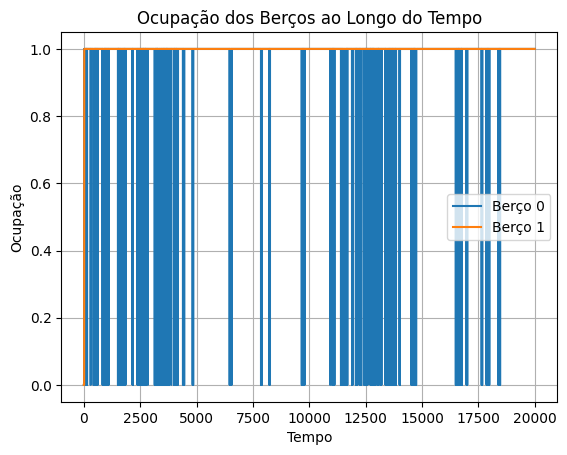

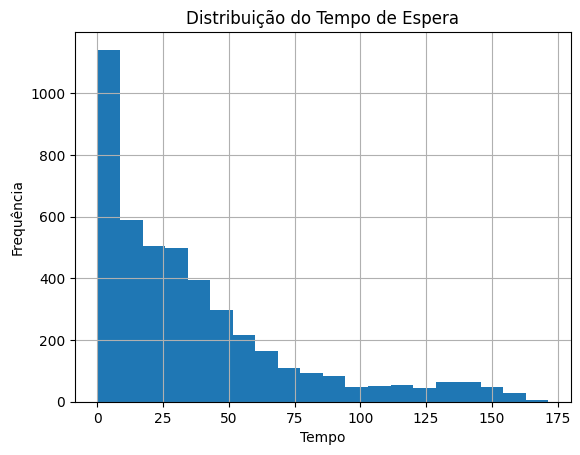

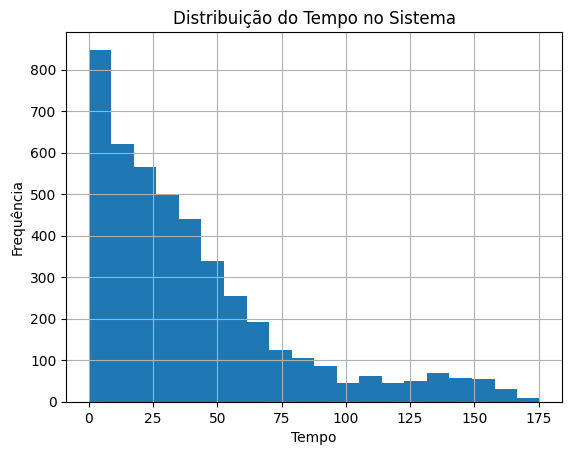

In [30]:
!pip install simpy
import simpy
import random
import statistics
import matplotlib.pyplot as plt

# --------------------------
# PARÂMETROS GERAIS
# --------------------------

LAMBDA = 1/3
MU = 1/4
TEMPO_SIM = 20000

# --------------------------
# COMPATIBILIDADE DOS NAVIOS
# --------------------------

def gerar_compatibilidade(i):
    """Compatibilidade atribuída de forma aleatória.
    """
    if i % 3 == 0:
        return [0]
    elif i % 3 == 1:
        return [1]
    else:
        return [0, 1]

# --------------------------
# ESTATÍSTICAS
# --------------------------

tempos_espera = []
tempos_sistema = []
fila_max = 0
total_navios = 0

# Para monitorar ocupação de cada berço
ocupacao_bercos = {0: [], 1: []}

# --------------------------
# PROCESSO DO NAVIO
# --------------------------

def navio(env, nome, berços, compatíveis):
    global fila_max, total_navios

    chegada = env.now
    total_navios += 1

    # Avaliar fila combinada dos berços compatíveis
    fila_atual = sum(len(berços[i].queue) for i in compatíveis)
    if fila_atual > fila_max:
        fila_max = fila_atual

    # Escolher berço compatível que liberar primeiro
    # Estratégia: criar uma lista de "requests" e esperar o primeiro
    reqs = [berços[i].request() for i in compatíveis]
    resultado = yield simpy.events.AnyOf(env, reqs)

    # Identificar qual berço aceitou a requisição
    for idx, req in enumerate(reqs):
        if req in resultado.events:
            berço_escolhido = compatíveis[idx]
            req_executado = req
            break

    inicio = env.now
    tempos_espera.append(inicio - chegada)

    # Tempo de serviço exponencial
    tempo_servico = random.expovariate(MU)
    yield env.timeout(tempo_servico)

    saida = env.now
    tempos_sistema.append(saida - chegada)

    # Libera o berço -> necessário quando não se usa a sintaxe "with.."
    berços[berço_escolhido].release(req_executado)


# --------------------------
# CHEGADAS DE NAVIOS (POISSON)
# --------------------------

def chegadas(env, berços):
    i = 0
    while True:
        intervalo = random.expovariate(LAMBDA)
        yield env.timeout(intervalo)
        i += 1

        compat = gerar_compatibilidade(i)
        env.process(navio(env, f"Navio {i}", berços, compat))


# --------------------------
# MONITOR DE OCUPAÇÃO
# --------------------------

def monitor_ocupacao(env, berços):
    while True:
        for i in range(len(berços)):
            ocupacao_bercos[i].append(berços[i].count)
        yield env.timeout(1)


# --------------------------
# EXECUÇÃO DA SIMULAÇÃO
# --------------------------

env = simpy.Environment()

# Dois berços independentes
berços = [
    simpy.Resource(env, capacity=1),
    simpy.Resource(env, capacity=1),
]

env.process(chegadas(env, berços))
env.process(monitor_ocupacao(env, berços))

env.run(until=TEMPO_SIM)

# --------------------------
# RESULTADOS
# --------------------------

print("\n===== RESULTADOS M/M/2 COM COMPATIBILIDADE =====")
print(f"Navios atendidos: {total_navios}")
print(f"Tempo médio de espera: {statistics.mean(tempos_espera):.3f}")
print(f"Tempo médio no sistema: {statistics.mean(tempos_sistema):.3f}")
print(f"Máxima fila observada: {fila_max}")
print("Ocupação média dos berços:")
for i in range(2):
    print(f"  Berço {i}: {statistics.mean(ocupacao_bercos[i]):.3f}")

# --------------------------
# GRÁFICOS
# --------------------------

# Ocupação dos berços
plt.figure()
plt.plot(ocupacao_bercos[0], label="Berço 0")
plt.plot(ocupacao_bercos[1], label="Berço 1")
plt.title("Ocupação dos Berços ao Longo do Tempo")
plt.xlabel("Tempo")
plt.ylabel("Ocupação")
plt.legend()
plt.grid()
plt.show()

# Tempo de espera
plt.figure()
plt.hist(tempos_espera, bins=20)
plt.title("Distribuição do Tempo de Espera")
plt.xlabel("Tempo")
plt.ylabel("Frequência")
plt.grid()
plt.show()

# Tempo no sistema
plt.figure()
plt.hist(tempos_sistema, bins=20)
plt.title("Distribuição do Tempo no Sistema")
plt.xlabel("Tempo")
plt.ylabel("Frequência")
plt.grid()
plt.show()
